In [1]:
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [2]:
data = pd.read_csv("./powerplant_data.csv");

In [3]:
data.head()

# AT->Temp
# V->Vacuum
# AP->pres
# RH->Humidity
# PE ->produce Energy

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [4]:
data.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [5]:
X = data.drop("PE",axis=1)
y = data["PE"]

In [6]:
X.head()

,AT,V,AP,RH
0,8.34,40.77,1010.84,90.01
1,23.64,58.49,1011.40,74.20
2,29.74,56.90,1007.15,41.91
3,19.07,49.69,1007.22,76.79
4,11.80,40.66,1017.13,97.20


In [7]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [8]:
data.shape

(9568, 5)

In [9]:
scaler = StandardScaler();
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
X_train_scaled

array([[ 0.74805289,  0.72006931, -0.32660017, -0.49711722],
       [ 0.86181948,  1.26515721, -0.98521113,  0.8181501 ],
       [ 0.93409473,  1.52314975,  0.32523844,  0.80167494],
       ...,
       [-0.22097078, -0.834965  ,  0.36756563, -0.83554456],
       [ 0.94747903,  1.14245344, -0.41971997, -0.45455637],
       [-1.77355014, -1.19049131,  1.92520594,  0.91837402]])

In [11]:
import torch
import torch.nn as  nn

In [12]:
X_train_tensor = torch.tensor(X_train_scaled,dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values,dtype=torch.float32).view(-1,1)
X_test_tensor = torch.tensor(X_test_scaled,dtype=torch.float32)
y_test_tensor =torch.tensor(y_test.values,dtype=torch.float32).view(-1,1)

In [17]:
# type(y_train)
# type(X_train_scaled)
# view(-1,-1)-to convert shape into [[1],[2],[3] ]

(7654,)

In [13]:
from torch.utils.data import TensorDataset,DataLoader
train_dataset = TensorDataset(X_train_tensor,y_train_tensor)
test_dataset = TensorDataset(X_test_tensor,y_test_tensor)

In [14]:
train_loader = DataLoader(train_dataset,batch_size = 32,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size = 32)

### Deep Learning

In [19]:
#Define ANN model

class ANN(nn.Module):
    def __init__(self):
        super(ANN,self).__init__()
        
        self.model = nn.Sequential(
            #1st Hidden layer
            nn.Linear(X_train.shape[1],6),
            nn.ReLU(),

            #2nd Layer
            nn.Linear(6,6),
            nn.ReLU(),

            #output
            nn.Linear(6,1),
        )
    def forward(self,x):
        return self.model(x)
            

In [20]:
import torch.optim as optim
model = ANN()

#loss,optimizer
criterion = nn.MSELoss();
optimizer = optim.Adam(model.parameters())

In [21]:
# Train the ANN
epochs = 100;
train_losses=[]
test_losses=[]
best_val_loss = float("inf");
for epoch in range(epochs):
    model.train()
    running_loss = 0.0 # training loss fro 1 epoch
    for xb,yb in train_loader:
        #xb -> features of one batch
        #yb -> label of one batch
        optimizer.zero_grad();
        outputs = model(xb) # predicted o/p for this batch
        loss = criterion(outputs,yb) # compute loss
        loss.backward() # back prop .. compute gradients 
        optimizer.step() # params update

        running_loss +=loss.item(); # converting loss tensor => py float
    epoch_train_loss = running_loss / len(train_loader) # avg loss per batch = train loss of one epoch
    train_losses.append(epoch_train_loss)

    # Validation
    running_val_loss = 0.0
    model.eval()
    with torch.no_grad(): # no compute of gradients - bco torch as auot grad which compute the gradients 
        for xb,yb in test_loader:
            outputs = model(xb);
            loss = criterion(outputs,yb)
            running_val_loss+=loss.item()
        
        epoch_val_loss = running_val_loss / len(test_loader)
        test_losses.append(epoch_val_loss)

        print(f"epoch {epoch+1}/{epochs} => train loss = {epoch_train_loss} & val loss= {epoch_val_loss}")
        if epoch_val_loss < best_val_loss :
            best_val_loss = epoch_val_loss
            torch.save(model.state_dict(),"best_model.pt")

epoch 1/100 => train loss = 205321.06809895832 & val loss= 202328.94765625
epoch 2/100 => train loss = 191981.32115885417 & val loss= 175872.53828125
epoch 3/100 => train loss = 149217.51510416667 & val loss= 118760.59908854167
epoch 4/100 => train loss = 87432.4359375 & val loss= 59653.779947916664
epoch 5/100 => train loss = 42130.894710286455 & val loss= 30358.65224609375
epoch 6/100 => train loss = 25291.41456705729 & val loss= 21919.418603515624
epoch 7/100 => train loss = 20137.154931640624 & val loss= 18114.025618489584
epoch 8/100 => train loss = 16639.882822672527 & val loss= 14833.950179036457
epoch 9/100 => train loss = 13404.080216471355 & val loss= 11643.122591145833
epoch 10/100 => train loss = 10236.793094889323 & val loss= 8595.506013997396
epoch 11/100 => train loss = 7305.873876953125 & val loss= 5832.953975423177
epoch 12/100 => train loss = 4513.374755350748 & val loss= 3270.8093994140627
epoch 13/100 => train loss = 2381.66149597168 & val loss= 1687.5142547607422
e

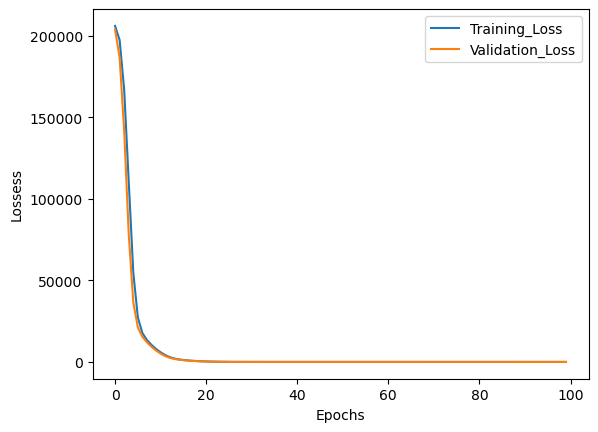

In [18]:
import matplotlib.pyplot as plt
loss_df = pd.DataFrame({
    "Training_Loss":train_losses,
    "Validation_Loss":test_losses
})
plt.plot(loss_df["Training_Loss"],label="Training_Loss");
plt.plot(loss_df["Validation_Loss"],label="Validation_Loss");
plt.xlabel("Epochs");
plt.ylabel("Lossess");
plt.legend();

In [22]:
#Loading best model
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [23]:
import torch

state_dict = torch.load("best_model.pt")
print(state_dict)

OrderedDict({'model.0.weight': tensor([[ 0.7268,  1.0640, -0.1879,  0.4026],
        [-0.5701, -1.0243,  0.2711,  0.1285],
        [-0.8088, -0.0945,  0.5346,  0.2319],
        [-0.7408, -1.0972, -0.4152, -0.4156],
        [ 0.7263,  0.7547, -0.0481, -0.4268],
        [-0.0689, -0.4607, -0.8825, -0.4142]]), 'model.0.bias': tensor([ 3.5347,  2.6700,  3.4675,  3.0682,  3.2780, -0.0592]), 'model.2.weight': tensor([[ 2.6825,  1.6879,  2.2326,  2.6435,  2.0148, -0.3582],
        [ 2.7275,  1.3728,  2.0512,  2.7009,  2.2498, -0.0264],
        [ 2.4705,  1.4136,  2.0044,  2.5242,  1.8052,  0.1174],
        [-0.0395, -0.3348,  0.0717, -0.0278, -0.3651,  0.1531],
        [ 2.1606,  1.8143,  2.6121,  2.4138,  2.1849, -0.3539],
        [ 2.8184,  1.5078,  2.1950,  2.6010,  2.2012, -0.4136]]), 'model.2.bias': tensor([ 2.1411,  2.8262,  2.4910, -0.1268,  2.1417,  2.7602]), 'model.4.weight': tensor([[ 2.5115,  2.1676,  2.5230, -0.2423,  2.4754,  2.2122]]), 'model.4.bias': tensor([1.6296])})


In [25]:
# Evaluation
model.eval();
with torch.no_grad():
    train_preds = model(X_train_tensor)
    test_preds = model(X_test_tensor)

    train_mse_loss = criterion(train_preds,y_train_tensor);
    test_mse_loss = criterion(test_preds,y_test_tensor);
print("Training MSE :",train_mse_loss.item());
print("Testing MSE :",test_mse_loss.item());

Training MSE : 19.905118942260742
Testing MSE : 18.437725067138672


In [28]:
from sklearn.metrics import r2_score
print("r2_score=",r2_score(y_test,test_preds))

r2_score= 0.9355649071497674


In [29]:
predicted_df = pd.DataFrame(test_preds.numpy(), columns=["Predicted Values"])
actual_df = pd.DataFrame(y_test.values, columns=["Actual Values"])

pd.concat([predicted_df, actual_df], axis=1)

,Predicted Values,Actual Values
0,434.494507,433.27
1,437.334778,438.16
2,461.020782,458.42
3,475.344055,480.82
4,435.745300,441.41
...,...,...
1909,452.175110,456.70
1910,431.819519,438.04
1911,467.657410,467.80
1912,431.497223,437.14
